In [1]:
import pandas as pd

df = pd.read_csv('logbook_assignment1.csv', low_memory=False)
print(f"Initial rows: {len(df)}")
print("="*60)

Initial rows: 1174870


### Percentage of date_fueled entries that are not proper dates

In [2]:
parsed_dates = pd.to_datetime(df['date_fueled'], format='%b %d %Y', errors='coerce')
invalid_count = parsed_dates.isna().sum()
invalid_pct = (invalid_count / len(df)) * 100
print(f"Invalid/missing date_fueled entries: {invalid_count} ({invalid_pct:.2f}%)")
print("="*60)

Invalid/missing date_fueled entries: 137210 (11.68%)


### Where date_fueled is invalid but date_captured is valid, use date_captured as a proxy

In [3]:
parsed_captured = pd.to_datetime(df['date_captured'], format='%b %d %Y', errors='coerce')
needs_proxy = parsed_dates.isna() & parsed_captured.notna()
print(f"Rows filled using date_captured as proxy: {needs_proxy.sum()}")
parsed_dates.loc[needs_proxy] = parsed_captured.loc[needs_proxy]
print(f"Remaining missing after proxy fill: {parsed_dates.isna().sum()}")
print("="*60)

Rows filled using date_captured as proxy: 137210
Remaining missing after proxy fill: 0


### Assign the cleaned column back

In [4]:
df['date_fueled'] = parsed_dates
df['date_captured'] = parsed_captured
print(f"date_fueled dtype: {df['date_fueled'].dtype}")
print(f"Missing date_fueled after proxy fill: {df['date_fueled'].isna().sum()}")
print("="*60)

date_fueled dtype: datetime64[ns]
Missing date_fueled after proxy fill: 0


### Remove dates in the future or earlier than 2005

In [5]:
today = pd.Timestamp.today()
before_count = len(df)

out_of_range = (df['date_fueled'] > today) | (df['date_fueled'] < pd.Timestamp('2005-01-01'))
print(f"Rows with out-of-range dates: {out_of_range.sum()}")

df = df[~out_of_range]
print(f"Rows before: {before_count}, after: {len(df)}, removed: {before_count - len(df)}")
print("="*60)

Rows with out-of-range dates: 570
Rows before: 1174870, after: 1174300, removed: 570


### Plot the distribution of fueling dates

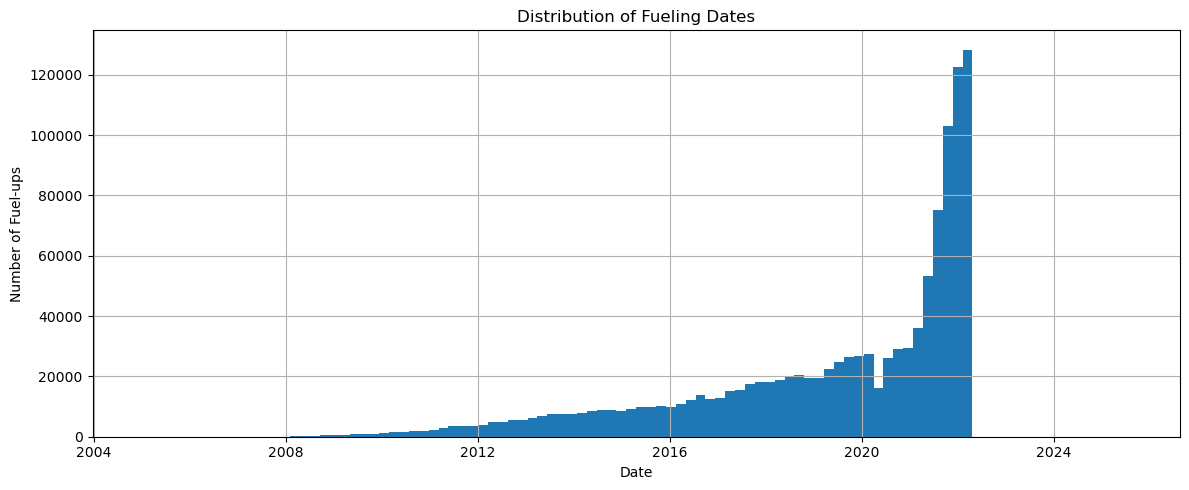

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
df['date_fueled'].dropna().hist(bins=100, ax=ax)
ax.set_title('Distribution of Fueling Dates')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Fuel-ups')
plt.tight_layout()
plt.show()

### Missing % on raw gallons/miles/odometer, before conversion

In [7]:
total_rows = len(df)
print("before conversion:")
for col in ['gallons', 'miles', 'odometer']:
    missing = df[col].isna().sum()
    pct = (missing / total_rows) * 100
    print(f"  {col}: {missing} missing ({pct:.2f}%)")
print("="*60)

before conversion:
  gallons: 74171 missing (6.32%)
  miles: 1028143 missing (87.55%)
  odometer: 149037 missing (12.69%)


### Convert to float (strip commas/whitespace first)

In [8]:
numeric_cols = ['gallons', 'miles', 'odometer', 'mpg']
for col in numeric_cols:
    df[col] = (
        df[col].astype(str)
        .str.strip()
        .str.replace(',', '', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(f"dtypes after conversion:\n{df[numeric_cols].dtypes}")
print("="*60)

dtypes after conversion:
gallons     float64
miles       float64
odometer    float64
mpg         float64
dtype: object


### Missing % after conversion

In [9]:
print("after conversion:")
for col in ['gallons', 'miles', 'odometer']:
    missing = df[col].isna().sum()
    pct = (missing / total_rows) * 100
    print(f"{col}: {missing} missing ({pct:.2f}%)")
print("="*60)

after conversion:
gallons: 74171 missing (6.32%)
miles: 1028143 missing (87.55%)
odometer: 149037 missing (12.69%)


### Fill missing values using miles/gallons/mpg interdependency

In [10]:
before = {col: df[col].isna().sum() for col in ['gallons', 'miles', 'mpg']}

can_fill_miles = df['miles'].isna() & df['gallons'].notna() & df['mpg'].notna()
df.loc[can_fill_miles, 'miles'] = df.loc[can_fill_miles, 'gallons'] * df.loc[can_fill_miles, 'mpg']

can_fill_gallons = df['gallons'].isna() & df['miles'].notna() & df['mpg'].notna() & (df['mpg'] != 0)
df.loc[can_fill_gallons, 'gallons'] = df.loc[can_fill_gallons, 'miles'] / df.loc[can_fill_gallons, 'mpg']

can_fill_mpg = df['mpg'].isna() & df['miles'].notna() & df['gallons'].notna() & (df['gallons'] != 0)
df.loc[can_fill_mpg, 'mpg'] = df.loc[can_fill_mpg, 'miles'] / df.loc[can_fill_mpg, 'gallons']

after = {col: df[col].isna().sum() for col in ['gallons', 'miles', 'mpg']}

print("Interdependency fill results:")
for col in ['gallons', 'miles', 'mpg']:
    filled = before[col] - after[col]
    print(f"{col}: filled {filled} values ({before[col]} -> {after[col]} missing)")
print("="*60)

Interdependency fill results:
gallons: filled 0 values (74171 -> 74171 missing)
miles: filled 953972 values (1028143 -> 74171 missing)
mpg: filled 0 values (74171 -> 74171 missing)


### Plot distributions

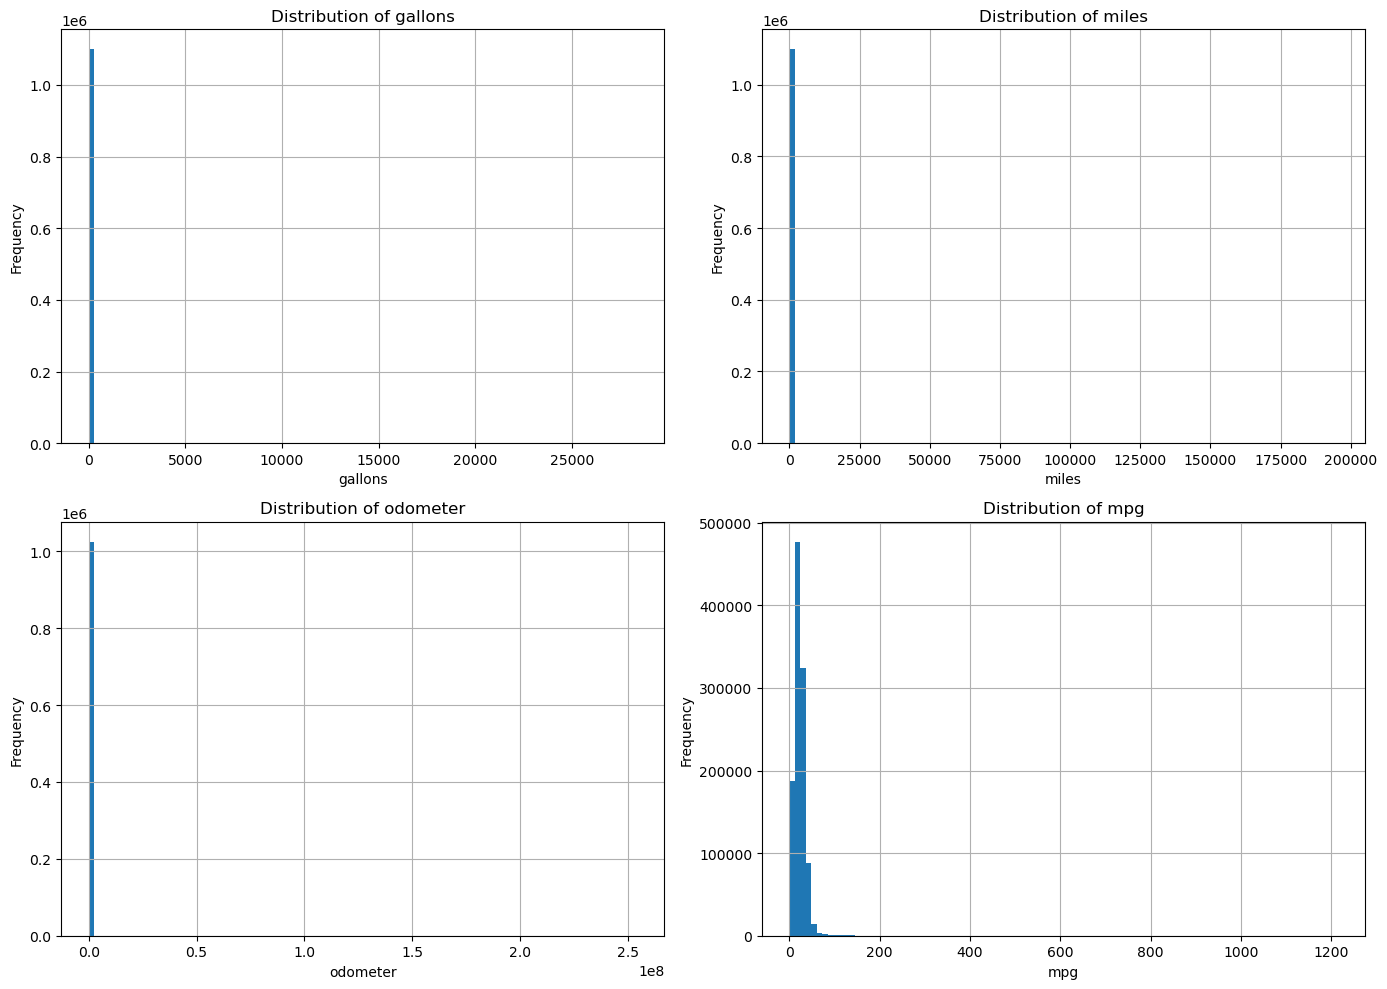

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ['gallons', 'miles', 'odometer', 'mpg']):
    df[col].dropna().hist(bins=100, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### Statistical description

In [12]:
stats_cols = ['gallons', 'miles', 'odometer', 'mpg']
desc = df[stats_cols].describe()
modes = df[stats_cols].mode().iloc[0]
desc.loc['mode'] = modes
print("Statistical description")
print(desc)

Statistical description
            gallons         miles      odometer           mpg
count  1.100129e+06  1.100129e+06  1.025263e+06  1.100129e+06
mean   1.279743e+01  2.694538e+02  1.040011e+05  2.216302e+01
std    7.448279e+01  7.257634e+02  3.405976e+05  1.574435e+01
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
25%    8.990000e+00  1.814000e+02  4.592400e+04  1.560000e+01
50%    1.195400e+01  2.670486e+02  9.188800e+04  2.180000e+01
75%    1.493900e+01  3.427641e+02  1.469255e+05  2.850000e+01
max    2.838000e+04  1.953212e+05  2.543621e+08  1.214300e+03
mode   1.056700e+01  0.000000e+00  1.000000e+00  0.000000e+00


### Converting the rest for memory's sake

In [13]:
#cost_per_gallon / total_spent: left as strings for now
print(f"cost_per_gallon dtype: {df['cost_per_gallon'].dtype}")
print(f"total_spent dtype:     {df['total_spent'].dtype}")
print("="*60)

#Downcast already-numeric measurement columns to float32
float_cols = ['odometer', 'miles', 'gallons', 'mpg']
print(f"Memory before float32 downcast: {df[float_cols].memory_usage(deep=True).sum() / 1024**2:.2f} MB")
for col in float_cols:
    df[col] = df[col].astype('float32')
print(f"Memory after float32 downcast:  {df[float_cols].memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("="*60)

#user_url as categorical
print(f"BEFORE user_url conversion: memory = {df['user_url'].memory_usage(deep=True) / 1024**2:.2f} MB")
df['user_url'] = df['user_url'].astype('category')
print(f"AFTER user_url conversion:  memory = {df['user_url'].memory_usage(deep=True) / 1024**2:.2f} MB")
print("="*60)

#Final summary
print(f"\nFINAL dtypes:\n{df.dtypes}")
print(f"\nFINAL missing values:\n{df.isna().sum()}")
print(f"\nFINAL total memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

cost_per_gallon dtype: object
total_spent dtype:     object
Memory before float32 downcast: 44.80 MB
Memory after float32 downcast:  26.88 MB
BEFORE user_url conversion: memory = 123.44 MB
AFTER user_url conversion:  memory = 29.19 MB

FINAL dtypes:
date_fueled        datetime64[ns]
date_captured      datetime64[ns]
odometer                  float32
gallons                   float32
cost_per_gallon            object
total_spent                object
mpg                       float32
miles                     float32
user_url                 category
dtype: object

FINAL missing values:
date_fueled             0
date_captured           0
odometer           149037
gallons             74171
cost_per_gallon     80719
total_spent         74171
mpg                 74171
miles               74171
user_url                0
dtype: int64

FINAL total memory: 191.67 MB


### Extracting currency and float amount

In [15]:
for col in ['cost_per_gallon', 'total_spent']:
    extracted = df[col].astype(str).str.extract(r'^([^\d]*)([\d,]+\.?\d*)')
    
    currency = extracted[0].str.strip()
    currency = currency.replace('', pd.NA)   # empty string -> NaN, not a currency
    
    amount = extracted[1].str.replace(',', '', regex=False)
    amount = pd.to_numeric(amount, errors='coerce')
    
    df[f'{col}_currency'] = currency.astype('category')
    df[f'{col}_value'] = amount.astype('float32')

print(df[['cost_per_gallon', 'cost_per_gallon_currency', 'cost_per_gallon_value',
          'total_spent', 'total_spent_currency', 'total_spent_value']].head(10))
print("="*60)

  cost_per_gallon cost_per_gallon_currency  cost_per_gallon_value total_spent  \
0             NaN                      NaN                    NaN         NaN   
1          $5.599                        $                  5.599      $67.86   
2           £5.45                        £                  5.450      £43.53   
3           £5.11                        £                  5.110      £54.00   
4          $3.029                        $                  3.029      $35.29   
5          $3.739                        $                  3.739      $12.76   
6          $4.639                        $                  4.639      $41.96   
7          $2.929                        $                  2.929      $43.82   
8             NaN                      NaN                    NaN         NaN   
9          $1.999                        $                  1.999       $5.42   

  total_spent_currency  total_spent_value  
0                  NaN                NaN  
1                   

### Extract car_make, car_model, car_year, user_id

In [21]:
url_parts = df['user_url'].astype(str).str.rstrip('/').str.split('/')
seg_count = url_parts.str.len()

df['car_make'] = pd.NA
df['car_model'] = pd.NA
df['car_year'] = pd.NA
df['user_id'] = pd.NA

#7-segment: make/model/year/id 
standard = seg_count == 7
df.loc[standard, 'car_make'] = url_parts[standard].str[-4]
df.loc[standard, 'car_model'] = url_parts[standard].str[-3]
df.loc[standard, 'car_year'] = url_parts[standard].str[-2]
df.loc[standard, 'user_id'] = url_parts[standard].str[-1]

#6-segment: make/model/id, (year missing) — first segment must be a known make
known_makes = set(url_parts[standard].str[-4].unique())
six_seg = seg_count == 6
first_seg = url_parts[six_seg].str[-3]
pattern_a = first_seg.isin(known_makes)

six_idx = df.loc[six_seg].index[pattern_a.values]
df.loc[six_idx, 'car_make'] = url_parts.loc[six_idx].str[-3]
df.loc[six_idx, 'car_model'] = url_parts.loc[six_idx].str[-2]
df.loc[six_idx, 'car_year'] = pd.NA
df.loc[six_idx, 'user_id'] = url_parts.loc[six_idx].str[-1]

#Everything else (6-seg Pattern B, 8-seg, any other odd structure) stays NaN — left unparsed

df['car_year'] = pd.to_numeric(df['car_year'], errors='coerce')
df['car_make'] = df['car_make'].astype('category')
df['car_model'] = df['car_model'].astype('category')

print(f"car_make missing: {df['car_make'].isna().sum()}")
print(f"car_model missing: {df['car_model'].isna().sum()}")
print(f"car_year missing: {df['car_year'].isna().sum()}")
print(f"user_id missing: {df['user_id'].isna().sum()}")
print(f"\nRows left fully unparsed (not standard, not Pattern A): {(~standard & ~six_seg.map(lambda x: False)).sum() if False else 'see below'}")

unparsed = df['car_make'].isna() & df['car_model'].isna()
print(f"Rows with make AND model both missing: {unparsed.sum()}")

car_make missing: 1216
car_model missing: 1216
car_year missing: 5062
user_id missing: 1216

Rows left fully unparsed (not standard, not Pattern A): see below
Rows with make AND model both missing: 1216


Notes here: 
I first got this:

- car_make missing: 0
- car_model missing: 0
- car_year missing: 3737
- user_id missing: 0

Rows with missing car_year: 3737

user_url
- auris               59
- cx-9                50
- accord              50
- odyssey             50
- 4runner             49
- pathfinder          47
- civic               42
- optima              41
- picanto             38
- wrangler            38
- f-350_super_duty    35
- matrix              34
- hilux               34
- tundra              33
- santa_fe            32
- corolla             31
- e320                31
- e-350_super_duty    31
- x3                  30
- pajero              30

Then I looked at URL Structure:

Segment count distribution:
user_url
- 7 = 1169238
- 6 = 4732
- 8 = 330

Segment count specifically for year-missing rows:
user_url
- 6 = 3737

These were the bad guys:
['https://www.somewebsite.com/kianival/2009/789684', 'https://www.somewebsite.com/kiaens/2012/511793', 'https://www.somewebsite.com/fiat/multipla/10363', 'https://www.somewebsite.com/land_rover/defender_90/841556', 'https://www.somewebsite.com/subaru/wrx_sti/680817', 'https://www.somewebsite.com/kianival/2007/801710', 'https://www.somewebsite.com/audi/q5/1000137', 'https://www.somewebsite.com/kiaens/2009/1025974', 'https://www.somewebsite.com/kianival/2006/80567', 'https://www.somewebsite.com/kianival/2009/789684', 'https://www.somewebsite.com/ford/explorer/193105', 'https://www.somewebsite.com/volkswagen/transporter/762428', 'https://www.somewebsite.com/toyota/yaris/1120723', 'https://www.somewebsite.com/volkswagen/transporter/762428', 'https://www.somewebsite.com/mercedes-benz/c250/686102', 'https://www.somewebsite.com/volkswagenavelle/1996/491811', 'https://www.somewebsite.com/nissan/versa/762979', 'https://www.somewebsite.com/honda/beat/572686', 'https://www.somewebsite.com/bmw/335i_xdrive/1053763', 'https://www.somewebsite.com/jeep/cj7/490985']

So
- Pattern A: make/model/id
- Pattern B: makemodel/year/id

I could extract pattern A. Pattarn B is too difficult

### litres filled

In [22]:
UK_GALLON_TO_LITRES = 4.54609

df['litres_filled'] = (df['gallons'] * UK_GALLON_TO_LITRES).astype('float32')

print(f"litres_filled missing: {df['litres_filled'].isna().sum()}")
print(df[['gallons', 'litres_filled']].head(10))
print("="*60)

litres_filled missing: 74171
   gallons  litres_filled
0      NaN            NaN
1   12.120      55.098610
2    7.991      36.327805
3   10.575      48.074902
4   11.651      52.966496
5    3.413      15.515805
6    9.044      41.114838
7   14.962      68.018600
8      NaN            NaN
9    2.710      12.319904


### km driven

In [23]:
MILES_TO_KM = 1.60934

df['km_driven'] = (df['miles'] * MILES_TO_KM).astype('float32')

print(f"km_driven missing: {df['km_driven'].isna().sum()}")
print(df[['miles', 'km_driven']].head(10))
print("="*60)

km_driven missing: 74171
        miles   km_driven
0         NaN         NaN
1  382.992004  616.364380
2  227.743500  366.516724
3  494.910004  796.478455
4  244.399994  393.322693
5   98.976997  159.287643
6  266.798004  429.368713
7  408.462585  657.355164
8         NaN         NaN
9    0.000000    0.000000


### litres/100km

In [24]:
valid_km = df['km_driven'].notna() & (df['km_driven'] != 0)

df['litres_per_100km'] = pd.NA
df.loc[valid_km, 'litres_per_100km'] = (
    df.loc[valid_km, 'litres_filled'] / df.loc[valid_km, 'km_driven'] * 100
)
df['litres_per_100km'] = pd.to_numeric(df['litres_per_100km'], errors='coerce').astype('float32')

print(f"litres_per_100km missing: {df['litres_per_100km'].isna().sum()}")
print(df[['litres_filled', 'km_driven', 'litres_per_100km']].head(10))
print("="*60)


litres_per_100km missing: 208921
   litres_filled   km_driven  litres_per_100km
0            NaN         NaN               NaN
1      55.098610  616.364380          8.939292
2      36.327805  366.516724          9.911636
3      48.074902  796.478455          6.035933
4      52.966496  393.322693         13.466422
5      15.515805  159.287643          9.740746
6      41.114838  429.368713          9.575648
7      68.018600  657.355164         10.347314
8            NaN         NaN               NaN
9      12.319904    0.000000               NaN


These missing values are interesting and worth looking into

In [26]:
print(df[['litres_filled', 'km_driven', 'litres_per_100km']].describe())

       litres_filled     km_driven  litres_per_100km
count   1.100129e+06  1.100129e+06     965379.000000
mean    5.817827e+01  4.336429e+02         14.615983
std     3.381327e+02  1.165776e+03         57.517986
min     0.000000e+00  0.000000e+00          0.000000
25%     4.086935e+01  2.919343e+02          9.479249
50%     5.434396e+01  4.297720e+02         12.123675
75%     6.791404e+01  5.516240e+02         15.520969
max     1.290180e+05  3.143382e+05      14923.504883
